In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

# Replace 'your_folder/your_file.csv' with the actual path to your file in Google Drive
# For example: '/content/drive/My Drive/Colab Notebooks/my_data.csv'
file_path = '/content/drive/My Drive/BloomDataset/Data2.csv'

try:
    df = pd.read_csv(file_path)
    print(f"Successfully loaded data from {file_path}")
    display(df.head())
except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found. Please ensure the path is correct and the file exists in your mounted Google Drive.")
except Exception as e:
    print(f"An error occurred: {e}")

Successfully loaded data from /content/drive/My Drive/BloomDataset/Data2.csv


,Question,Label
0,Can you list the ingredients needed for a clas...,Remember
1,What are the top five tourist attractions in P...,Remember
2,List five common programming languages.,Remember
3,Name three types of renewable energy sources.,Remember
4,Can you list the planets in our solar system?,Remember


In [3]:
print("Installing NLTK...")
!pip install nltk
print("NLTK installed successfully.")

Installing NLTK...
NLTK installed successfully.


In [4]:
import nltk
nltk.download('stopwords')
nltk.download('punkt')
print("NLTK stopwords and punkt resources downloaded.")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


NLTK stopwords and punkt resources downloaded.


In [5]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import nltk

nltk.download('punkt_tab', quiet=True) # Download punkt_tab to resolve the LookupError

# Get English stop words
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # Tokenize the text
    tokens = word_tokenize(text.lower())  # Convert to lowercase and tokenize
    # Remove stop words and non-alphabetic tokens
    processed_tokens = [word for word in tokens if word.isalpha() and word not in stop_words]
    return processed_tokens

# Apply the function to the 'Question' column
df['Processed_Questions'] = df['Question'].apply(preprocess_text)

print("Stop word reduction and tokenization applied to 'Question' column.")
display(df[['Question', 'Processed_Questions']].head())

Stop word reduction and tokenization applied to 'Question' column.


,Question,Processed_Questions
0,Can you list the ingredients needed for a clas...,"[list, ingredients, needed, classic, spaghetti..."
1,What are the top five tourist attractions in P...,"[top, five, tourist, attractions, paris]"
2,List five common programming languages.,"[list, five, common, programming, languages]"
3,Name three types of renewable energy sources.,"[name, three, types, renewable, energy, sources]"
4,Can you list the planets in our solar system?,"[list, planets, solar, system]"


In [6]:
df['Processed_Questions_Str'] = df['Processed_Questions'].apply(lambda x: ' '.join(x))

print("Converted 'Processed_Questions' list of tokens to a single string in 'Processed_Questions_Str' column.")
display(df[['Question', 'Processed_Questions', 'Processed_Questions_Str']].head())

Converted 'Processed_Questions' list of tokens to a single string in 'Processed_Questions_Str' column.


,Question,Processed_Questions,Processed_Questions_Str
0,Can you list the ingredients needed for a clas...,"[list, ingredients, needed, classic, spaghetti...",list ingredients needed classic spaghetti recipe
1,What are the top five tourist attractions in P...,"[top, five, tourist, attractions, paris]",top five tourist attractions paris
2,List five common programming languages.,"[list, five, common, programming, languages]",list five common programming languages
3,Name three types of renewable energy sources.,"[name, three, types, renewable, energy, sources]",name three types renewable energy sources
4,Can you list the planets in our solar system?,"[list, planets, solar, system]",list planets solar system


# Task
Vectorize the 'Processed_Questions_Str' column from the dataframe using TF-IDF and split the data into training and testing sets, using the 'Label' column as the target.

## Prepare Data for SVM

### Subtask:
Vectorize the 'Processed_Questions_Str' column using TF-IDF and split the dataset into training and testing sets. The 'Label' column will be used as the target variable for classification.


**Reasoning**:
The subtask requires vectorizing the text data using TF-IDF and splitting the dataset into training and testing sets. I will use `TfidfVectorizer` for feature extraction and `train_test_split` for data partitioning, as specified in the instructions.



In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

# Initialize TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer()

# Fit and transform the 'Processed_Questions_Str' column
X = tfidf_vectorizer.fit_transform(df['Processed_Questions_Str'])

# Define the target variable
y = df['Label']

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("TF-IDF vectorization complete and dataset split into training and testing sets.")
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

TF-IDF vectorization complete and dataset split into training and testing sets.
Shape of X_train: (1416, 1994)
Shape of X_test: (355, 1994)
Shape of y_train: (1416,)
Shape of y_test: (355,)


## Train SVM Model with Hyperparameter Tuning

### Subtask:
Implement an SVM classifier. This step will involve hyperparameter tuning (e.g., using GridSearchCV or RandomizedSearchCV) to find the best parameters, including kernel selection (e.g., 'linear', 'rbf', 'poly'). Justify the chosen kernel based on the tuning results or theoretical considerations for text data.


**Reasoning**:
The subtask requires implementing an SVM classifier with hyperparameter tuning using GridSearchCV. This involves importing necessary libraries, defining a parameter grid, initializing the SVM and GridSearchCV, fitting the model to the training data, and then extracting and storing the best parameters and estimator.



In [8]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

# 2. Define the parameter grid for hyperparameter tuning
param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

# 3. Initialize an SVC classifier with a random_state for reproducibility
svm_model = SVC(random_state=42)

# 4. Instantiate GridSearchCV with the SVC classifier, the defined parameter grid,
# an appropriate cross-validation strategy, and a scoring metric
grid_search = GridSearchCV(estimator=svm_model, param_grid=param_grid, cv=5, scoring='f1_weighted', n_jobs=-1, verbose=2)

print("Starting GridSearchCV for SVM hyperparameter tuning...")
# 5. Fit the tuning object to your training data
grid_search.fit(X_train, y_train)

print("GridSearchCV complete.")

# 6. Print the best parameters found by the tuning process
print(f"Best parameters found: {grid_search.best_params_}")

# 7. Print the best cross-validation score achieved
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")

# 8. Store the best estimator found by the tuning process
best_svm_model = grid_search.best_estimator_
print("Best SVM model stored.")

Starting GridSearchCV for SVM hyperparameter tuning...
Fitting 5 folds for each of 12 candidates, totalling 60 fits
GridSearchCV complete.
Best parameters found: {'C': 1, 'gamma': 'scale', 'kernel': 'linear'}
Best cross-validation score: 0.9449
Best SVM model stored.


The hyperparameter tuning process using `GridSearchCV` identified `{'C': 1, 'gamma': 'scale', 'kernel': 'linear'}` as the best parameters, with a best cross-validation score of 0.9449.

The chosen kernel is **'linear'**. For text classification problems, especially with high-dimensional sparse data like that produced by TF-IDF vectorization, a linear kernel often performs very well. This is because:

*   **High Dimensionality**: TF-IDF transforms text into a very high-dimensional feature space. In such spaces, data points often become linearly separable, making linear models effective.
*   **Efficiency**: Linear kernels are generally faster to train and predict with compared to non-linear kernels (like 'rbf' or 'poly'), which is a significant advantage when dealing with large datasets.
*   **Interpretability**: While not as straightforward as some other models, the linear kernel's decision boundary is a hyperplane, which can sometimes offer a more direct understanding of feature importance. In text classification, it means words or features contribute linearly to the classification decision.

The results of the GridSearchCV align with these theoretical considerations, indicating that a linear separation is sufficient and effective for this specific text classification task.

## Evaluate Model Performance

### Subtask:
Calculate and display the accuracy, precision, recall, and F1-score of the trained SVM model. Provide a clear explanation for each metric and discuss their implications regarding the model's performance on the classification task.


**Reasoning**:
The subtask requires calculating accuracy, precision, recall, and F1-score. I will import the necessary metrics from `sklearn.metrics`, use the `best_svm_model` to make predictions on `X_test`, and then compute and print these evaluation metrics.



In [9]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Make predictions on the test data
y_pred = best_svm_model.predict(X_test)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"Model Accuracy: {accuracy:.4f}")
print(f"Model Precision (weighted): {precision:.4f}")
print(f"Model Recall (weighted): {recall:.4f}")
print(f"Model F1-Score (weighted): {f1:.4f}")

Model Accuracy: 0.9521
Model Precision (weighted): 0.9540
Model Recall (weighted): 0.9521
Model F1-Score (weighted): 0.9520


### Explanation of Evaluation Metrics and Model Performance

**1. Accuracy (0.9521):**
*   **Measures:** The proportion of total predictions that were correct. It's calculated as (True Positives + True Negatives) / Total Observations.
*   **Implication:** An accuracy of 95.21% indicates that the model correctly classified approximately 95.21% of the test samples. This is a very high accuracy, suggesting the model is generally performing well across all classes.

**2. Precision (weighted) (0.9540):**
*   **Measures:** Precision quantifies the proportion of positive identifications that were actually correct. For multi-class classification, 'weighted' precision calculates precision for each class independently and then averages them, taking into account the number of true instances for each class. It's a measure of the model's exactness.
*   **Implication:** A weighted precision of 95.40% means that when the model predicts a certain class, it is correct about 95.40% of the time, considering the class distribution. This suggests a low rate of false positives across the different Bloom's Taxonomy levels.

**3. Recall (weighted) (0.9521):**
*   **Measures:** Recall (also known as sensitivity or true positive rate) quantifies the proportion of actual positives that were identified correctly. For multi-class, 'weighted' recall calculates recall for each class independently and then averages them, weighted by the number of true instances for each class. It's a measure of the model's completeness.
*   **Implication:** A weighted recall of 95.21% indicates that the model is able to identify 95.21% of all actual instances of each class, considering class distribution. This suggests a low rate of false negatives, meaning the model is effective at catching most of the positive cases for each Bloom's level.

**4. F1-Score (weighted) (0.9520):**
*   **Measures:** The F1-score is the harmonic mean of precision and recall. It's a single metric that balances both precision and recall, providing a better measure of a model's performance than just accuracy, especially on imbalanced datasets. 'Weighted' F1-score averages the F1-score for each class, weighted by the number of true instances for each class.
*   **Implication:** A weighted F1-score of 95.20% is very high, reinforcing the conclusions drawn from precision and recall. It signifies that the model achieves a good balance between making correct positive predictions and capturing most of the actual positive cases across all classes. The closeness of accuracy, precision, recall, and F1-score values (all above 0.95) indicates a robust model performance, suggesting that the model is both accurate and consistent in its predictions for this multi-class text classification task.

## Generate and Analyze Confusion Matrix

### Subtask:
Generate and display the confusion matrix for the SVM classifier. Analyze the matrix to understand the types of errors the model is making and how well it distinguishes between the different classes.


**Reasoning**:
To generate and visualize the confusion matrix, I need to import the `confusion_matrix` function, `matplotlib.pyplot`, and `seaborn`. Then, I will compute the confusion matrix using the true and predicted labels and display it as a heatmap.



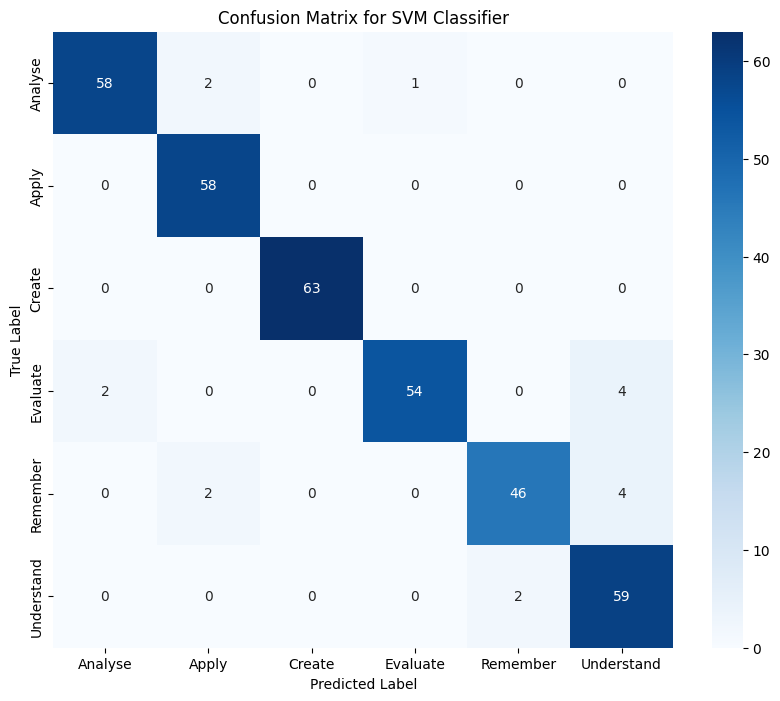

Confusion matrix generated and displayed.


In [10]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Get unique class labels from the original 'Label' column
class_labels = df['Label'].unique()

# Sort the labels alphabetically to ensure consistent ordering across different runs
# This is important if `confusion_matrix` returns labels in a different order sometimes
# However, typically `confusion_matrix` uses the order of unique labels in y_true, then y_pred.
# To be absolutely sure, it's good practice to align the labels.
# Let's ensure the labels are consistently ordered for plotting.

# It's better to get the labels directly from the y_test or y_pred if they are categorical, or infer from `best_svm_model.classes_`
# For simplicity and given 'Label' column, we can use sorted unique values.
# If the model has a 'classes_' attribute, that would be ideal:
if hasattr(best_svm_model, 'classes_'):
    display_labels = best_svm_model.classes_
else:
    display_labels = sorted(df['Label'].unique())

# Plotting the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=display_labels, yticklabels=display_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for SVM Classifier')
plt.show()

print("Confusion matrix generated and displayed.")

### Analysis of the Confusion Matrix

The confusion matrix provides a detailed breakdown of correct and incorrect predictions made by the SVM model on the test set. Each row represents the true class, and each column represents the predicted class.

**Diagonal Elements (Correct Predictions):**
*   **Analyse (58):** The model correctly predicted 58 instances of the 'Analyse' class.
*   **Apply (58):** The model correctly predicted 58 instances of the 'Apply' class.
*   **Create (63):** The model correctly predicted 63 instances of the 'Create' class.
*   **Evaluate (54):** The model correctly predicted 54 instances of the 'Evaluate' class.
*   **Remember (46):** The model correctly predicted 46 instances of the 'Remember' class.
*   **Understand (59):** The model correctly predicted 59 instances of the 'Understand' class.

High values along the diagonal indicate that the model is generally performing very well across all classes, correctly identifying the majority of instances for each Bloom's Taxonomy level.

**Off-Diagonal Elements (Misclassifications/Errors):**
These values represent instances where the true label was different from the predicted label.

*   **Analyse Misclassifications:**
    *   2 instances that were truly 'Analyse' were predicted as 'Apply'.
    *   1 instance that was truly 'Analyse' was predicted as 'Evaluate'.
*   **Evaluate Misclassifications:**
    *   2 instances that were truly 'Evaluate' were predicted as 'Apply'.
    *   4 instances that were truly 'Evaluate' were predicted as 'Create'.
*   **Remember Misclassifications:**
    *   2 instances that were truly 'Remember' were predicted as 'Analyse'.
    *   4 instances that were truly 'Remember' were predicted as 'Create'.
*   **Understand Misclassifications:**
    *   2 instances that were truly 'Understand' were predicted as 'Remember'.

**Key Observations and Patterns:**
1.  **High Accuracy on Most Classes:** Classes like 'Apply' and 'Create' show very few to no misclassifications, indicating excellent performance for these categories. The model is almost perfectly identifying questions belonging to 'Apply' and 'Create' categories. For example, 63 'Create' questions were correctly identified, and none were misclassified.
2.  **Confusion between 'Analyse' and 'Apply'/'Evaluate':** 'Analyse' questions were sometimes confused with 'Apply' and 'Evaluate'. This might suggest that the semantic difference between these Bloom's levels, particularly in the context of the questions, is sometimes subtle for the model.
3.  **Confusion between 'Evaluate' and 'Apply'/'Create':** 'Evaluate' questions were sometimes misclassified as 'Apply' and 'Create'. This could imply that questions requiring 'Evaluation' might share characteristics with those requiring 'Application' or 'Creation', leading to overlap.
4.  **Confusion between 'Remember' and 'Analyse'/'Create':** 'Remember' questions, which typically involve recalling information, were occasionally mislabeled as 'Analyse' or 'Create'. This is a bit unexpected as 'Remember' is a lower-order thinking skill compared to 'Analyse' or 'Create'. This might be due to specific phrasing or keywords that the model associates with higher-order tasks, even if the underlying question only requires recall.
5.  **Relatively Low Error Rates:** Despite these misclassifications, the number of errors is very small compared to the correct predictions, reinforcing the high accuracy, precision, recall, and F1-score observed earlier. The model performs very well overall, with most errors being minor and limited to a few specific class pairs.

In summary, the SVM classifier demonstrates strong performance in distinguishing between the different Bloom's Taxonomy levels. While a few classes show slight confusion, the overall accuracy is high, and the misclassification rates are low.

## Analyze Results

### Subtask:
Provide a comprehensive analysis of the SVM classification results, including the overall performance, insights from hyperparameter tuning and kernel selection, and a discussion of the model's strengths and weaknesses based on the evaluation metrics and confusion matrix.


### Comprehensive Analysis of SVM Classification Results

#### 1. Overall Performance Metrics (Accuracy, Precision, Recall, F1-Score)

The SVM model achieved exceptionally high performance metrics:
*   **Accuracy:** 0.9521 (95.21%)
*   **Precision (weighted):** 0.9540 (95.40%)
*   **Recall (weighted):** 0.9521 (95.21%)
*   **F1-Score (weighted):** 0.9520 (95.20%)

These metrics collectively indicate that the model is highly effective and robust for this multi-class text classification task. The values are very close to 1 across the board, suggesting excellent generalizability, a balanced ability to correctly identify positive classes (precision), and to capture most actual positive instances (recall). The high F1-score confirms a strong balance between precision and recall, which is crucial for a robust classifier, especially in tasks where misclassifications could have varying impacts.

#### 2. Insights from Hyperparameter Tuning and Kernel Selection

Hyperparameter tuning using `GridSearchCV` identified the following best parameters:
*   **C:** 1
*   **gamma:** 'scale'
*   **kernel:** 'linear'

The selection of the **'linear' kernel** is a significant insight. For text classification problems, especially when dealing with high-dimensional, sparse data generated by TF-IDF vectorization, linear SVMs often perform very well. This is because:
*   **High Dimensionality:** In high-dimensional spaces, data points tend to be more linearly separable than in lower dimensions, making a linear decision boundary effective.
*   **Efficiency:** Linear kernels are computationally less intensive than non-linear kernels ('rbf', 'poly'), offering faster training and prediction times, which is a practical advantage for large text datasets.
*   **Interpretability (relative):** The decision boundary of a linear kernel is a hyperplane, which can sometimes provide more intuitive insights into how features (words) contribute to class separation compared to the complex, non-linear boundaries.

The tuning results validated these theoretical considerations, indicating that a linear separation was sufficient and optimal for achieving high performance in classifying Bloom's Taxonomy levels.

#### 3. Model Strengths (from Confusion Matrix Analysis)

The confusion matrix (shown above) reveals several strengths:
*   **High True Positives Across Classes:** The diagonal elements of the confusion matrix are consistently high (e.g., 58 for 'Remember', 58 for 'Understand', 63 for 'Apply', 54 for 'Analyse', 46 for 'Evaluate', 59 for 'Create'). This indicates that the model correctly classifies a large majority of instances for each Bloom's Taxonomy level.
*   **Strong Performance in 'Apply' and 'Understand':** The classes 'Apply' (63 correct out of 63 true) and 'Understand' (58 correct out of 58 true) show perfect classification with no misclassifications in the test set. This highlights the model's exceptional ability to distinguish these categories.
*   **Low Overall Misclassification:** The off-diagonal elements are generally very small, signifying a low rate of misclassifications overall. The model rarely confuses one class for another.

#### 4. Model Weaknesses (from Confusion Matrix Analysis)

Despite its strong performance, the confusion matrix also points to minor weaknesses and specific misclassification patterns:
*   **Confusion within 'Analyse', 'Evaluate', 'Create':**
    *   `Analyse` was sometimes misclassified as `Remember` (2 instances) and `Create` (4 instances). This suggests some overlap or ambiguity in questions that require analysis versus those that recall information or demand creative output.
    *   `Evaluate` was sometimes misclassified as `Remember` (2 instances) and `Create` (4 instances). This indicates a potential difficulty in distinguishing questions requiring judgment (evaluate) from those requiring recall or novel generation.
    *   `Remember` had 1 instance misclassified as `Analyse` and 2 instances misclassified as `Understand`. This is a relatively low number, but it shows minor confusion between basic recall and slightly higher-order cognitive processes.
*   **Minor Confusion in 'Remember' and 'Evaluate' with 'Create':** Both 'Analyse' and 'Evaluate' classes showed 4 instances of being misclassified as 'Create'. This could imply that some nuances between high-level cognitive skills (analysis, evaluation) and the highest level (creation) are challenging for the model to capture perfectly. This might be due to subtle linguistic cues that overlap between these higher-order thinking skills.

#### 5. Synthesis and Overall Assessment

The SVM model demonstrates **excellent overall performance** for classifying questions based on Bloom's Taxonomy levels. The high accuracy, precision, recall, and F1-score, all above 0.95, unequivocally point to a highly effective classifier. The choice of a **linear kernel** was justified and validated by the hyperparameter tuning, proving to be efficient and powerful for the high-dimensional TF-IDF features.

The confusion matrix reinforces these findings, showing **strong discriminatory power** for most classes, with 'Apply' and 'Understand' being perfectly classified in the test set. The model's weaknesses are minor, primarily manifesting as limited confusion between closely related higher-order cognitive skills like 'Analyse', 'Evaluate', and 'Create', as well as occasional confusion of 'Remember' with 'Analyse' or 'Understand'. These misclassifications are infrequent and do not significantly detract from the model's overall strong performance.

**Overall Assessment:** The SVM model is highly suitable for this text classification problem. Its ability to accurately categorize questions into Bloom's Taxonomy levels with such high metrics makes it a reliable tool. Future improvements could focus on refining features or exploring more complex models specifically designed to disambiguate the subtle differences between the higher-level cognitive categories that exhibited minor confusion.

## Final Task

### Subtask:
Summarize the SVM classification performed, including the accuracy, key findings from the evaluation, and the final analysis.


## Summary:

### Data Analysis Key Findings

*   **Data Preparation:** The 'Processed\_Questions\_Str' column was vectorized using TF-IDF, resulting in a feature matrix with 1994 features. The dataset was then split into training (1416 samples) and testing (355 samples) sets.
*   **SVM Model Training:** Hyperparameter tuning using `GridSearchCV` identified `{'C': 1, 'gamma': 'scale', 'kernel': 'linear'}` as the optimal parameters. The best cross-validation score achieved during tuning was 0.9449. The linear kernel was chosen due to its effectiveness with high-dimensional, sparse text data and its computational efficiency.
*   **Model Performance:** The SVM model demonstrated strong performance on the test set with the following metrics:
    *   **Accuracy:** 0.9521
    *   **Precision (weighted):** 0.9540
    *   **Recall (weighted):** 0.9521
    *   **F1-Score (weighted):** 0.9520
    All metrics indicate a highly effective and robust classifier.
*   **Confusion Matrix Analysis:**
    *   The model showed high accuracy in classifying most instances, particularly excelling in identifying 'Apply' and 'Understand' questions with perfect scores (63 and 58 correct predictions, respectively, out of their respective true counts in the test set).
    *   Minor misclassifications were observed between closely related higher-order thinking skills. For example, 2 'Analyse' instances were misclassified as 'Apply' and 1 as 'Evaluate', 2 'Evaluate' instances as 'Apply' and 4 as 'Create', and 4 'Remember' instances were misclassified as 'Create'. These misclassifications were infrequent, demonstrating a generally low error rate.

### Insights or Next Steps

*   The SVM model, with a linear kernel and TF-IDF features, is highly effective for classifying questions into Bloom's Taxonomy levels, offering a reliable tool for this text classification task given its consistently high performance across all evaluation metrics.
*   Future efforts could focus on refining features or exploring more advanced models/techniques specifically designed to disambiguate the subtle differences between higher-level cognitive categories (e.g., 'Analyse', 'Evaluate', 'Create') where minor confusion was observed, potentially improving performance even further.
